# Лабораторная работа 4

### Реализация однослойной сети и перцептрона с одним скрытым слоем для бинарной классификации.

В ноутбуке реализованы:
- генерация двух датасетов
- разбиение на train / validation / test в пропорции 60% / 20% / 20%
- функции активации BReLU и Sigmoid
- бинарная cross-entropy
- SGD с регулируемым размером батча
- Adam как связка Momentum + RMSProp
- однослойная сеть
- сеть с одним скрытым слоем
- подбор гиперпараметров по validation F1
- итоговая проверка на test

In [59]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons, make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score,f1_score,confusion_matrix,classification_report)

SEED = 466290

def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)

seed_everything(SEED)

## 1. Генерация датасетов

In [60]:
def make_datasets(seed=SEED):
    X1, y1 = make_moons(n_samples=400,noise=0.15,random_state=seed)

    X2, y2 = make_classification(n_samples=200,n_features=5,n_redundant=2,
        n_informative=2,n_clusters_per_class=2,n_classes=2,random_state=seed)

    return {"make_moons": (X1, y1),
        "make_classification": (X2, y2)}

datasets = make_datasets()

for name, (X, y) in datasets.items():
    print(name)
    print("X shape:", X.shape)
    print("y shape:", y.shape)
    print("class balance:", np.bincount(y))
    print()

make_moons
X shape: (400, 2)
y shape: (400,)
class balance: [200 200]

make_classification
X shape: (200, 5)
y shape: (200,)
class balance: [101  99]



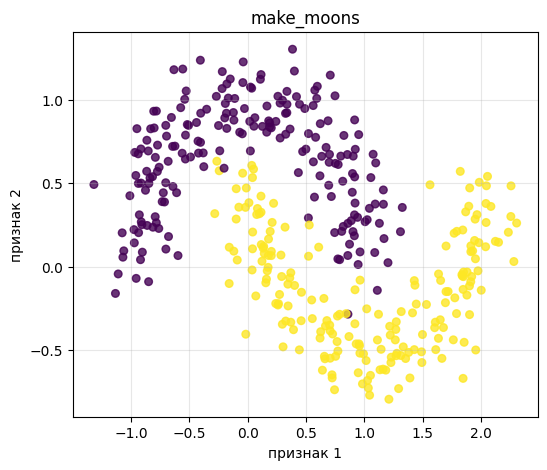

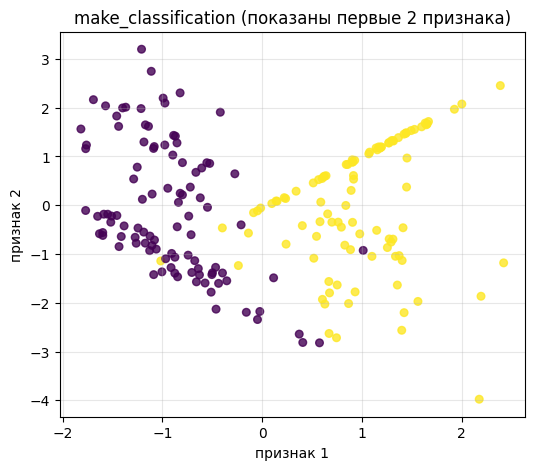

In [58]:
def plot_dataset(X, y, title):
    plt.figure(figsize=(6, 5))
    if X.shape[1] == 2:
        plt.scatter(X[:, 0], X[:, 1], c=y, s=30, alpha=0.8)
        plt.xlabel("признак 1")
        plt.ylabel("признак 2")
    else:
        plt.scatter(X[:, 0], X[:, 1], c=y, s=30, alpha=0.8)
        plt.xlabel("признак 1")
        plt.ylabel("признак 2")
        plt.title(title + " (показаны первые 2 признака)")
        plt.grid(alpha=0.3)
        plt.show()
        return
    plt.title(title)
    plt.grid(alpha=0.3)
    plt.show()

for name, (X, y) in datasets.items():
    plot_dataset(X, y, name)

## 2. Разделение данных и стандартизация

Данные делятся на: train (60%), validation (20%), test (20%)

In [61]:
def split_and_scale(X, y, seed=SEED):
    X_train, X_temp, y_train, y_temp = train_test_split(X, y,test_size=0.40,
        random_state=seed,stratify=y)

    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp,test_size=0.50,
        random_state=seed,stratify=y_temp)

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)
    X_test = scaler.transform(X_test)

    y_train = y_train.reshape(-1, 1)
    y_val = y_val.reshape(-1, 1)
    y_test = y_test.reshape(-1, 1)

    return X_train, X_val, X_test, y_train, y_val, y_test

prepared = {}

for name, (X, y) in datasets.items():
    prepared[name] = split_and_scale(X, y)
    X_train, X_val, X_test, y_train, y_val, y_test = prepared[name]
    print(name)
    print("train:", X_train.shape, y_train.shape)
    print("validation:", X_val.shape, y_val.shape)
    print("test:", X_test.shape, y_test.shape)
    print()

make_moons
train: (240, 2) (240, 1)
validation: (80, 2) (80, 1)
test: (80, 2) (80, 1)

make_classification
train: (120, 5) (120, 1)
validation: (40, 5) (40, 1)
test: (40, 5) (40, 1)



## 3. Активации и функция потерь

In [62]:
def brelu(z):
    return np.minimum(np.maximum(z, 0), 1)


def brelu_derivative(z):
    return ((z > 0) & (z < 1)).astype(float)


def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))


def sigmoid_derivative_from_output(a):
    return a * (1 - a)


def binary_cross_entropy(y_true, y_pred):
    eps = 1e-12
    y_pred = np.clip(y_pred, eps, 1 - eps)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))


def predict_labels(y_pred, threshold=0.5):
    return (y_pred >= threshold).astype(int)

## 4. Оптимизаторы

Реализованы два варианта:
1. SGD с регулируемым размером батча
2. Adam, сочетание Momentum и RMSProp

In [63]:
class SGDOptimizer:
    def __init__(self, lr=0.01):
        self.lr = lr

    def update(self, params, grads):
        for key in params:
            params[key] -= self.lr * grads[key]


class AdamOptimizer:
    def __init__(self, lr=0.01, beta1=0.9, beta2=0.999, eps=1e-8):
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps
        self.m = {}
        self.v = {}
        self.t = 0

    def update(self, params, grads):
        if not self.m:
            for key in params:
                self.m[key] = np.zeros_like(params[key])
                self.v[key] = np.zeros_like(params[key])

        self.t += 1

        for key in params:
            self.m[key] = self.beta1 * self.m[key] + (1 - self.beta1) * grads[key]
            self.v[key] = self.beta2 * self.v[key] + (1 - self.beta2) * (grads[key] ** 2)

            m_hat = self.m[key] / (1 - self.beta1 ** self.t)
            v_hat = self.v[key] / (1 - self.beta2 ** self.t)

            params[key] -= self.lr * m_hat / (np.sqrt(v_hat) + self.eps)

## 5. Однослойная сеть


In [64]:
class SingleLayerNetwork:
    def __init__(self, input_dim, seed=SEED):
        rng = np.random.default_rng(seed)
        self.params = {"W": rng.normal(0, 0.1, size=(input_dim, 1)),
            "b": np.zeros((1, 1))}

    def forward(self, X):
        z = X @ self.params["W"] + self.params["b"]
        y_pred = sigmoid(z)
        cache = {"X": X, "z": z, "y_pred": y_pred}
        return y_pred, cache

    def backward(self, cache, y_true):
        X = cache["X"]
        y_pred = cache["y_pred"]
        m = X.shape[0]

        dz = (y_pred - y_true) / m

        grads = {"W": X.T @ dz,
            "b": np.sum(dz, axis=0, keepdims=True)}

        return grads

    def predict_proba(self, X):
        y_pred, _ = self.forward(X)
        return y_pred

    def predict(self, X):
        return predict_labels(self.predict_proba(X))

## 6. Перцептрон с одним скрытым слоем


In [65]:
class OneHiddenLayerNetwork:
    def __init__(self, input_dim, hidden_dim=8, seed=SEED):
        rng = np.random.default_rng(seed)

        self.params = {
            "W1": rng.normal(0, np.sqrt(2 / input_dim), size=(input_dim, hidden_dim)),
            "b1": np.zeros((1, hidden_dim)),
            "W2": rng.normal(0, np.sqrt(2 / hidden_dim), size=(hidden_dim, 1)),
            "b2": np.zeros((1, 1))}

    def forward(self, X):
        z1 = X @ self.params["W1"] + self.params["b1"]
        a1 = brelu(z1)
        z2 = a1 @ self.params["W2"] + self.params["b2"]
        y_pred = sigmoid(z2)

        cache = {
            "X": X,
            "z1": z1,
            "a1": a1,
            "z2": z2,
            "y_pred": y_pred
        }

        return y_pred, cache

    def backward(self, cache, y_true):
        X = cache["X"]
        z1 = cache["z1"]
        a1 = cache["a1"]
        y_pred = cache["y_pred"]
        m = X.shape[0]

        dz2 = (y_pred - y_true) / m

        dW2 = a1.T @ dz2
        db2 = np.sum(dz2, axis=0, keepdims=True)

        da1 = dz2 @ self.params["W2"].T
        dz1 = da1 * brelu_derivative(z1)

        dW1 = X.T @ dz1
        db1 = np.sum(dz1, axis=0, keepdims=True)

        grads = {
            "W1": dW1,
            "b1": db1,
            "W2": dW2,
            "b2": db2
        }

        return grads

    def predict_proba(self, X):
        y_pred, _ = self.forward(X)
        return y_pred

    def predict(self, X):
        return predict_labels(self.predict_proba(X))

## 7. Обучение модели

In [66]:
def iterate_minibatches(X, y, batch_size, shuffle=True):
    indices = np.arange(X.shape[0])

    if shuffle:
        np.random.shuffle(indices)

    for start in range(0, X.shape[0], batch_size):
        batch_idx = indices[start:start + batch_size]
        yield X[batch_idx], y[batch_idx]


def train_model(
    model,
    X_train,
    y_train,
    X_val,
    y_val,
    optimizer_name="adam",
    lr=0.01,
    batch_size=32,
    epochs=1000,
    patience=100,
    verbose=False
):
    if optimizer_name.lower() == "sgd":
        optimizer = SGDOptimizer(lr=lr)
    elif optimizer_name.lower() == "adam":
        optimizer = AdamOptimizer(lr=lr)
    else:
        raise ValueError("optimizer_name должен быть 'sgd' или 'adam'")

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_f1": [],
        "val_f1": [],
        "train_acc": [],
        "val_acc": []
    }

    best_val_f1 = -1
    best_params = None
    no_improve = 0

    for epoch in range(1, epochs + 1):
        for X_batch, y_batch in iterate_minibatches(X_train, y_train, batch_size):
            y_pred, cache = model.forward(X_batch)
            grads = model.backward(cache, y_batch)
            optimizer.update(model.params, grads)

        train_pred = model.predict_proba(X_train)
        val_pred = model.predict_proba(X_val)

        train_loss = binary_cross_entropy(y_train, train_pred)
        val_loss = binary_cross_entropy(y_val, val_pred)

        train_labels = predict_labels(train_pred)
        val_labels = predict_labels(val_pred)

        train_f1 = f1_score(y_train, train_labels)
        val_f1 = f1_score(y_val, val_labels)

        train_acc = accuracy_score(y_train, train_labels)
        val_acc = accuracy_score(y_val, val_labels)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_f1"].append(train_f1)
        history["val_f1"].append(val_f1)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_params = {key: value.copy() for key, value in model.params.items()}
            no_improve = 0
        else:
            no_improve += 1

        if verbose and epoch % 100 == 0:
            print(
                f"epoch={epoch:4d} "
                f"train_loss={train_loss:.4f} "
                f"val_loss={val_loss:.4f} "
                f"train_f1={train_f1:.4f} "
                f"val_f1={val_f1:.4f}"
            )

        if no_improve >= patience:
            if verbose:
                print(f"Early stopping на эпохе {epoch}")
            break

    if best_params is not None:
        model.params = best_params

    return model, history, best_val_f1

## 8. Подбор гиперпараметров

Подбор выполняется по validation F1.  
Находим максимальный F1 на валидационной выборке.

In [67]:
def run_experiment(dataset_name, model_type, optimizer_name, lr, batch_size, hidden_dim=None, epochs=1500):
    X_train, X_val, X_test, y_train, y_val, y_test = prepared[dataset_name]

    if model_type == "single":
        model = SingleLayerNetwork(input_dim=X_train.shape[1], seed=SEED)
    elif model_type == "hidden":
        model = OneHiddenLayerNetwork(input_dim=X_train.shape[1], hidden_dim=hidden_dim, seed=SEED)

    model, history, best_val_f1 = train_model(model,X_train,y_train,X_val,y_val,optimizer_name=optimizer_name,
        lr=lr,batch_size=batch_size,epochs=epochs,patience=200,verbose=False)

    val_pred = model.predict(X_val)
    test_pred = model.predict(X_test)

    result = {
        "dataset": dataset_name,
        "model_type": model_type,
        "optimizer": optimizer_name,
        "lr": lr,
        "batch_size": batch_size,
        "hidden_dim": hidden_dim if hidden_dim is not None else "-",
        "val_f1": f1_score(y_val, val_pred),
        "val_accuracy": accuracy_score(y_val, val_pred),
        "test_f1": f1_score(y_test, test_pred),
        "test_accuracy": accuracy_score(y_test, test_pred),
        "model": model,
        "history": history}

    return result


def grid_search(dataset_name):
    results = []
    configs = []

    for optimizer_name in ["sgd", "adam"]:
        for lr in [0.001, 0.005, 0.01, 0.05]:
            for batch_size in [16, 32, 64]:
                configs.append({
                    "model_type": "single",
                    "optimizer_name": optimizer_name,
                    "lr": lr,
                    "batch_size": batch_size,
                    "hidden_dim": None})

    for optimizer_name in ["sgd", "adam"]:
        for lr in [0.001, 0.005, 0.01, 0.05]:
            for batch_size in [16, 32, 64]:
                for hidden_dim in [4, 8, 16, 32]:
                    configs.append({
                        "model_type": "hidden",
                        "optimizer_name": optimizer_name,
                        "lr": lr,
                        "batch_size": batch_size,
                        "hidden_dim": hidden_dim})

    for cfg in configs:
        result = run_experiment(
            dataset_name=dataset_name,
            model_type=cfg["model_type"],
            optimizer_name=cfg["optimizer_name"],
            lr=cfg["lr"],
            batch_size=cfg["batch_size"],
            hidden_dim=cfg["hidden_dim"])
        results.append(result)

    table = pd.DataFrame([
        {k: v for k, v in r.items() if k not in ["model", "history"]}
        for r in results])

    table = table.sort_values(by=["val_f1", "val_accuracy"], ascending=False).reset_index(drop=True)

    return table, results

In [51]:
all_tables = {}
all_results = {}

for dataset_name in prepared:
    print("Подбор для датасета:", dataset_name)
    table, results = grid_search(dataset_name)
    all_tables[dataset_name] = table
    all_results[dataset_name] = results

    display(table.head(10))
    print()

Подбор для датасета: make_moons


,dataset,model_type,optimizer,lr,batch_size,hidden_dim,val_f1,val_accuracy,test_f1,test_accuracy
0,make_moons,hidden,adam,0.050,16,4,0.987654,0.9875,0.962025,0.9625
1,make_moons,hidden,adam,0.050,16,8,0.987654,0.9875,0.987342,0.9875
2,make_moons,hidden,adam,0.050,16,16,0.987654,0.9875,0.974359,0.9750
3,make_moons,hidden,adam,0.050,16,32,0.987654,0.9875,1.000000,1.0000
4,make_moons,hidden,adam,0.050,32,4,0.987654,0.9875,0.975000,0.9750
5,make_moons,hidden,adam,0.050,32,8,0.987654,0.9875,0.962025,0.9625
6,make_moons,hidden,adam,0.050,32,16,0.987654,0.9875,0.962025,0.9625
7,make_moons,hidden,adam,0.050,32,32,0.987654,0.9875,0.974359,0.9750
8,make_moons,hidden,adam,0.001,16,32,0.975610,0.9750,0.974359,0.9750
9,make_moons,hidden,adam,0.001,32,32,0.975610,0.9750,0.974359,0.9750



Подбор для датасета: make_classification


,dataset,model_type,optimizer,lr,batch_size,hidden_dim,val_f1,val_accuracy,test_f1,test_accuracy
0,make_classification,single,adam,0.001,16,-,1.0,1.0,0.974359,0.975
1,make_classification,single,adam,0.001,32,-,1.0,1.0,0.974359,0.975
2,make_classification,single,adam,0.001,64,-,1.0,1.0,0.974359,0.975
3,make_classification,single,adam,0.005,16,-,1.0,1.0,0.974359,0.975
4,make_classification,single,adam,0.005,32,-,1.0,1.0,0.974359,0.975
5,make_classification,single,adam,0.005,64,-,1.0,1.0,0.974359,0.975
6,make_classification,single,adam,0.010,16,-,1.0,1.0,0.974359,0.975
7,make_classification,single,adam,0.010,32,-,1.0,1.0,0.974359,0.975
8,make_classification,single,adam,0.010,64,-,1.0,1.0,0.974359,0.975
9,make_classification,single,adam,0.050,16,-,1.0,1.0,0.923077,0.925


## 9. Выбор лучших моделей

In [52]:
def find_best_result(dataset_name):
    table = all_tables[dataset_name]
    results = all_results[dataset_name]
    best_row = table.iloc[0]

    for r in results:
        same_hidden = str(r["hidden_dim"]) == str(best_row["hidden_dim"])
        if (
            r["model_type"] == best_row["model_type"] and
            r["optimizer"] == best_row["optimizer"] and
            r["lr"] == best_row["lr"] and
            r["batch_size"] == best_row["batch_size"] and
            same_hidden):
            return r

best_results = {}

for dataset_name in prepared:
    best_results[dataset_name] = find_best_result(dataset_name)

summary = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ["model", "history"]}
    for r in best_results.values()])

summary

,dataset,model_type,optimizer,lr,batch_size,hidden_dim,val_f1,val_accuracy,test_f1,test_accuracy
0,make_moons,hidden,adam,0.050,16,4,0.987654,0.9875,0.962025,0.9625
1,make_classification,single,adam,0.001,16,-,1.000000,1.0000,0.974359,0.9750


## 10. Графики обучения

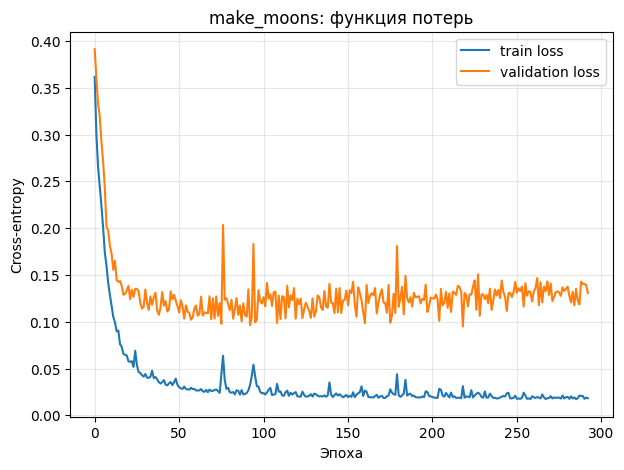

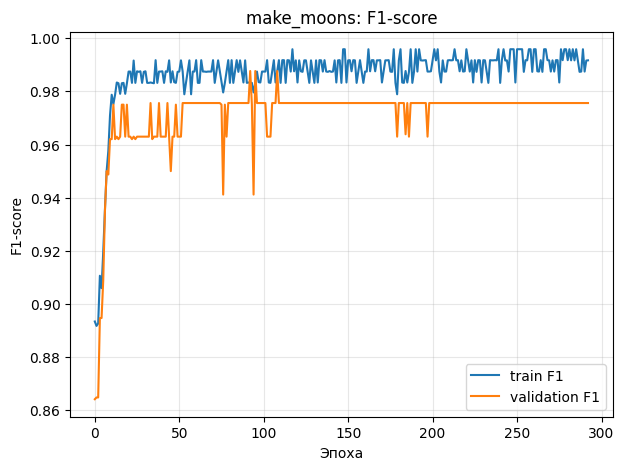

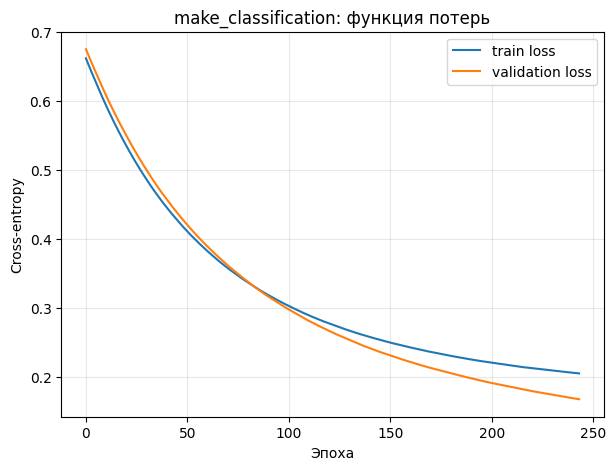

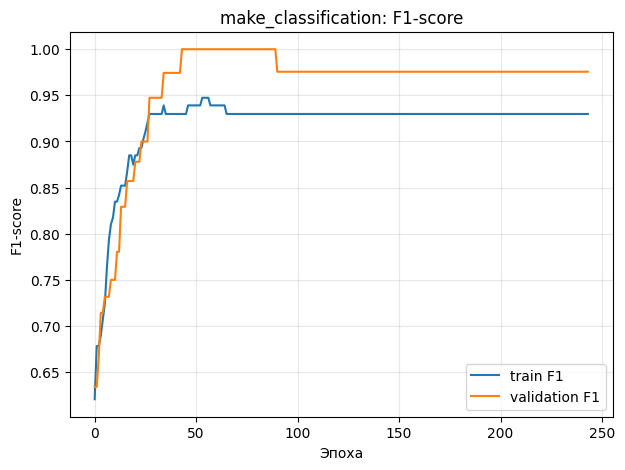

In [70]:
def plot_history(history, title):
    plt.figure(figsize=(7, 5))
    plt.plot(history["train_loss"], label="train loss")
    plt.plot(history["val_loss"], label="validation loss")
    plt.xlabel("Эпоха")
    plt.ylabel("Cross-entropy")
    plt.title(title + ": функция потерь")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    plt.figure(figsize=(7, 5))
    plt.plot(history["train_f1"], label="train F1")
    plt.plot(history["val_f1"], label="validation F1")
    plt.xlabel("Эпоха")
    plt.ylabel("F1-score")
    plt.title(title + ": F1-score")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

for dataset_name, result in best_results.items():
    plot_history(result["history"], f"{dataset_name}")

## 11. Проверка на тестовой выборке

In [69]:
def evaluate_best_model(dataset_name, result):
    X_train, X_val, X_test, y_train, y_val, y_test = prepared[dataset_name]
    model = result["model"]

    y_test_pred = model.predict(X_test)

    print()
    print(dataset_name)
    print("Лучшая модель:")
    print("Тип:", result["model_type"])
    print("Оптимизатор:", result["optimizer"])
    print("learning rate:", result["lr"])
    print("batch size:", result["batch_size"])
    print("hidden_dim:", result["hidden_dim"])
    print()
    print("Test accuracy:", accuracy_score(y_test, y_test_pred))
    print("Test F1:", f1_score(y_test, y_test_pred))
    print()
    print("Confusion matrix:")
    print(confusion_matrix(y_test, y_test_pred))
    print()
    print("Classification report:")
    print(classification_report(y_test, y_test_pred, digits=4))

for dataset_name, result in best_results.items():
    evaluate_best_model(dataset_name, result)


make_moons
Лучшая модель:
Тип: hidden
Оптимизатор: adam
learning rate: 0.05
batch size: 16
hidden_dim: 4

Test accuracy: 0.9625
Test F1: 0.9620253164556962

Confusion matrix:
[[39  1]
 [ 2 38]]

Classification report:
              precision    recall  f1-score   support

           0     0.9512    0.9750    0.9630        40
           1     0.9744    0.9500    0.9620        40

    accuracy                         0.9625        80
   macro avg     0.9628    0.9625    0.9625        80
weighted avg     0.9628    0.9625    0.9625        80


make_classification
Лучшая модель:
Тип: single
Оптимизатор: adam
learning rate: 0.001
batch size: 16
hidden_dim: -

Test accuracy: 0.975
Test F1: 0.9743589743589743

Confusion matrix:
[[20  0]
 [ 1 19]]

Classification report:
              precision    recall  f1-score   support

           0     0.9524    1.0000    0.9756        20
           1     1.0000    0.9500    0.9744        20

    accuracy                         0.9750        40
   macro

## 12. Визуализация границы решений для *make_moons*

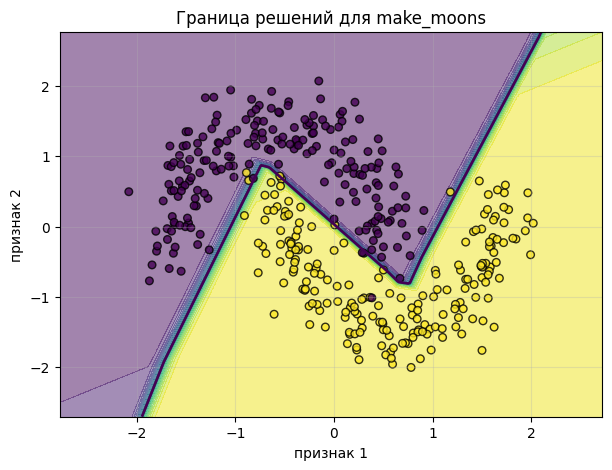

In [71]:
def plot_decision_boundary(model, X, y, title):
    x_min, x_max = X[:, 0].min() - 0.7, X[:, 0].max() + 0.7
    y_min, y_max = X[:, 1].min() - 0.7, X[:, 1].max() + 0.7

    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),np.linspace(y_min, y_max, 300))

    grid = np.c_[xx.ravel(), yy.ravel()]
    probs = model.predict_proba(grid).reshape(xx.shape)

    plt.figure(figsize=(7, 5))
    plt.contourf(xx, yy, probs, levels=20, alpha=0.5)
    plt.contour(xx, yy, probs, levels=[0.5], linewidths=2)
    plt.scatter(X[:, 0], X[:, 1], c=y.ravel(), s=30, edgecolor="k", alpha=0.8)
    plt.xlabel("признак 1")
    plt.ylabel("признак 2")
    plt.title(title)
    plt.grid(alpha=0.3)
    plt.show()

X_train, X_val, X_test, y_train, y_val, y_test = prepared["make_moons"]
X_all = np.vstack([X_train, X_val, X_test])
y_all = np.vstack([y_train, y_val, y_test])

plot_decision_boundary(best_results["make_moons"]["model"],X_all,y_all,"Граница решений для make_moons")

## 13. Сравнение однослойной сети и сети со скрытым слоем

In [56]:
comparison_rows = []

for dataset_name in prepared:
    table = all_tables[dataset_name]

    best_single = table[table["model_type"] == "single"].iloc[0]
    best_hidden = table[table["model_type"] == "hidden"].iloc[0]

    comparison_rows.append({
        "dataset": dataset_name,
        "model": "однослойная сеть",
        "optimizer": best_single["optimizer"],
        "lr": best_single["lr"],
        "batch_size": best_single["batch_size"],
        "hidden_dim": "-",
        "val_f1": best_single["val_f1"],
        "test_f1": best_single["test_f1"],
        "test_accuracy": best_single["test_accuracy"]})

    comparison_rows.append({
        "dataset": dataset_name,
        "model": "сеть с одним скрытым слоем",
        "optimizer": best_hidden["optimizer"],
        "lr": best_hidden["lr"],
        "batch_size": best_hidden["batch_size"],
        "hidden_dim": best_hidden["hidden_dim"],
        "val_f1": best_hidden["val_f1"],
        "test_f1": best_hidden["test_f1"],
        "test_accuracy": best_hidden["test_accuracy"]})

comparison = pd.DataFrame(comparison_rows)
comparison

,dataset,model,optimizer,lr,batch_size,hidden_dim,val_f1,test_f1,test_accuracy
0,make_moons,однослойная сеть,adam,0.010,32,-,0.857143,0.868421,0.8750
1,make_moons,сеть с одним скрытым слоем,adam,0.050,16,4,0.987654,0.962025,0.9625
2,make_classification,однослойная сеть,adam,0.001,16,-,1.000000,0.974359,0.9750
3,make_classification,сеть с одним скрытым слоем,sgd,0.001,16,16,1.000000,0.918919,0.9250


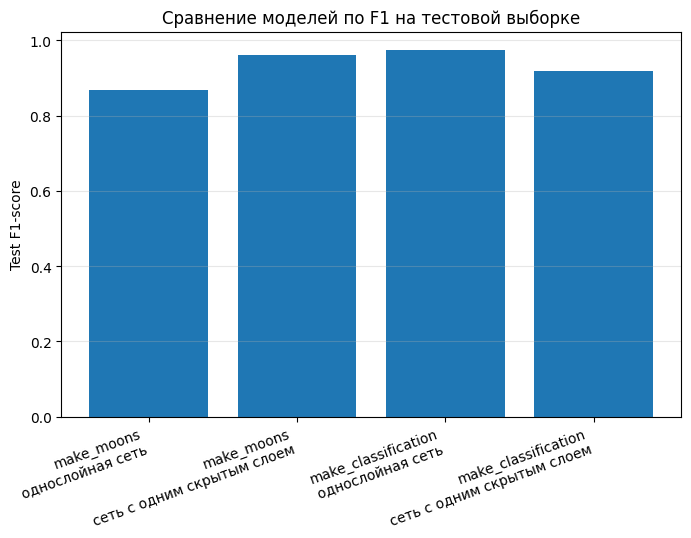

In [57]:
plt.figure(figsize=(8, 5))
labels = comparison["dataset"] + "\n" + comparison["model"]
plt.bar(labels, comparison["test_f1"])
plt.ylabel("Test F1-score")
plt.title("Сравнение моделей по F1 на тестовой выборке")
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.show()